In [5]:
#libray loading
library(dplyr)
library(readr)
library(tidyverse)
library(ggplot2)
library(patchwork)
library(RColorBrewer)
library(ggrepel)

In [22]:
output_dir <- "outputs"

In [6]:
#reading TCGA data to variables
tcga_cancer <- read.csv("data/tcga_cancer.csv")
tcga_labels <- read.csv("data/tcga_cancer_labels.csv")


#selecting the first 43 genes and first 200 observations
selected_genes <- tcga_cancer[0:200, 3:45]  
selected_gene_labels <- tcga_labels[1:200,]

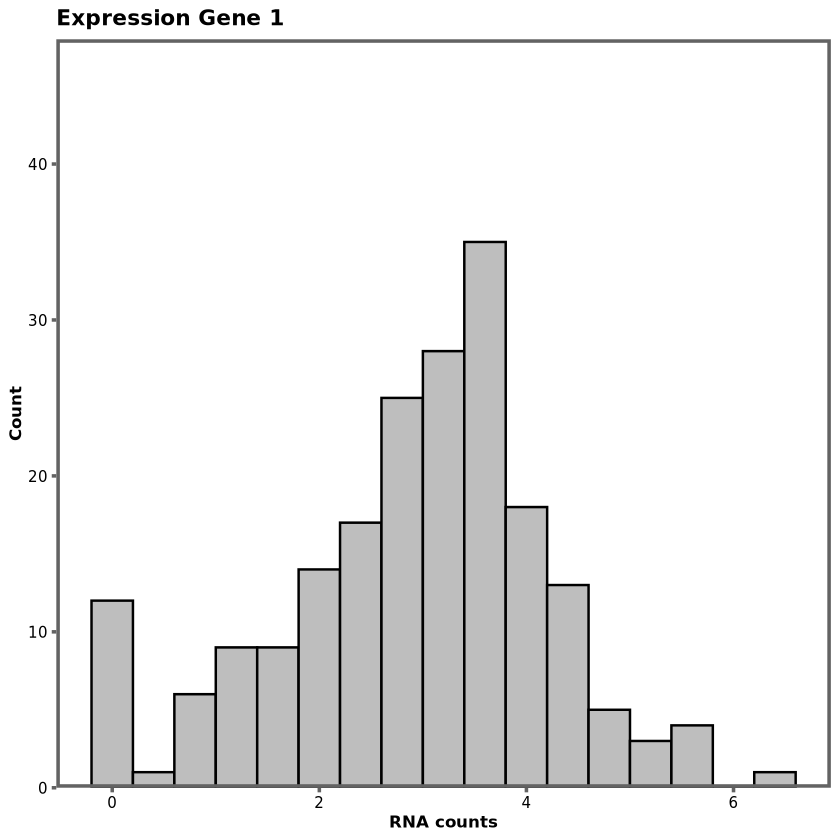

In [23]:
#plotting gene 1 on histogram
histogram_plot <- ggplot(selected_genes, aes(x = gene_1)) +
  geom_histogram(binwidth = 0.4,
                 fill = "gray",
                 colour = "black",
                 linewidth = 0.7) +
  scale_y_continuous(expand = c(0, 0), 
                     limits = c(0,48)) +
  labs(title = "Expression Gene 1",
       x = "RNA counts",
       y = "Count") +
  theme(panel.grid = element_blank(),
        panel.background = element_rect(fill = "white"),
        panel.border = element_rect(color = "#636363", linewidth = 2, fill = NA),
        plot.title = element_text(size = 13, face = "bold"),
        axis.title = element_text(size = 10, face = "bold"),
        axis.text = element_text(size = 9, color = "black"),
        axis.ticks = element_line(color = "#636363", linewidth = 1)
  )
ggsave(file.path(output_dir, "tcga_gene1_histogram.png"), 
       histogram_plot, width = 6, height = 5, dpi = 300)
print(histogram_plot)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


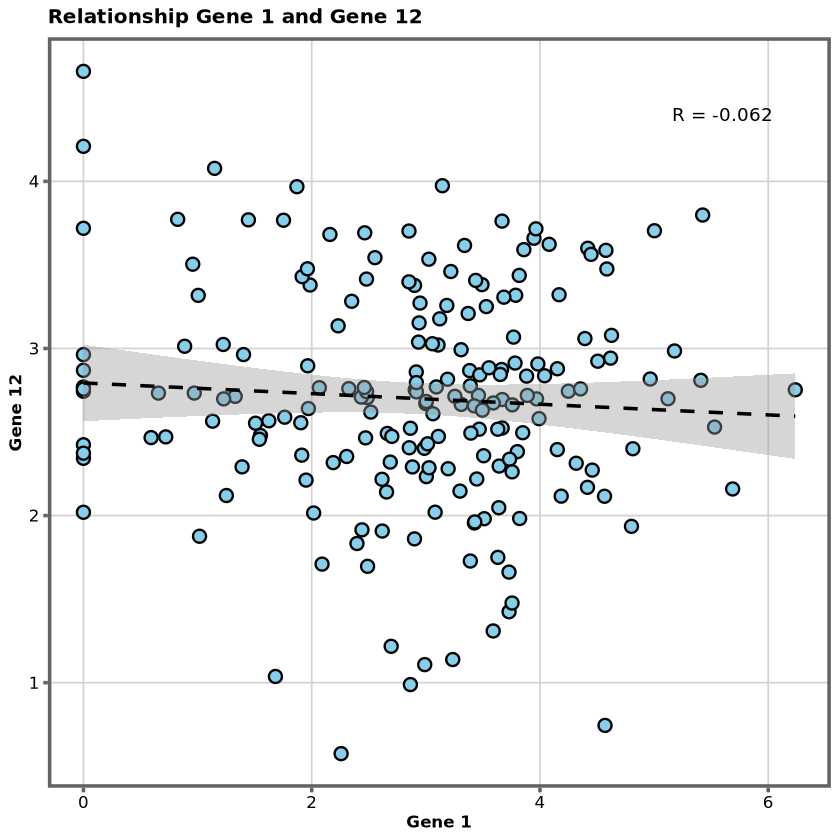

In [25]:
#gene 1 and gene 12 expression correlation
#calculation pearson correlation
pearson_correlation <- cor(x = selected_genes$gene_1, y = selected_genes$gene_12)

#plotting gene 1 and gene 12 using scatter plot
scatter_plot <- ggplot(selected_genes, aes(x = gene_1 ,y = gene_12)) + 
  geom_point(shape = 21, 
             colour = "black", 
             fill = "skyblue", 
             size = 3,
             stroke = 1) + 
  annotate("text", x = 5.6, 
           y = 4.4, 
           label = paste("R =", round(pearson_correlation, 3))) +
  geom_smooth(method = "lm", 
              linetype = "dashed", 
              linewidth = 1, 
              colour = "black") +
  labs(title = "Relationship Gene 1 and Gene 12",
       x = "Gene 1",
       y = "Gene 12") +
  theme(panel.grid.major.x = element_line(color = "lightgray"),
        panel.grid.major.y = element_line(color = "lightgray"),
        panel.background = element_rect(fill = "white"),
        panel.border = element_rect(color = "#636363", size = 2, fill = NA),
        plot.title = element_text(size = 12, face = "bold"),
        axis.title = element_text(size = 10, face = "bold"),
        axis.text = element_text(size = 10, color = "black"),
        axis.ticks = element_line(color = "#636363", linewidth = 1)
  )
ggsave(file.path(output_dir, "tcga_gene1_gene12_scatter.png"), 
       scatter_plot, width = 6, height = 5, dpi = 300)
print(scatter_plot)

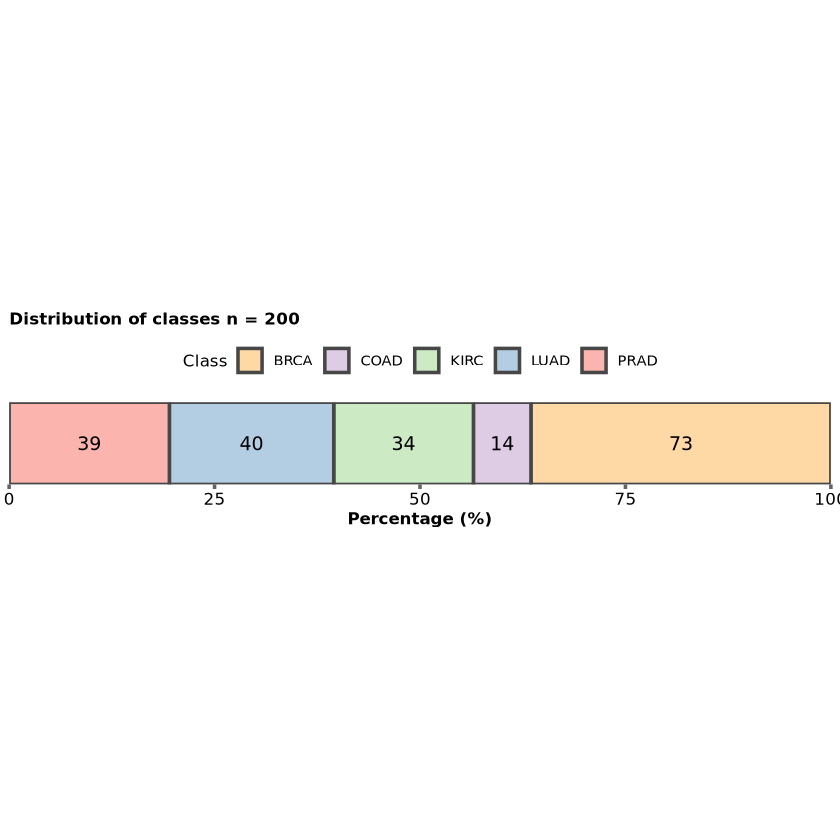

In [26]:
#stack bar chart
class_counts <- selected_gene_labels %>%
  count(Class) %>%
  mutate(percentage = n / sum(n) * 100)

stacked_bar_plot <- ggplot(class_counts, aes(x = 1, y = percentage, fill = Class)) + 
  geom_bar(stat = "identity" ,
           color = "#474747",
           linewidth = 1,
           position = "stack",
           width = 0.5) + 
  geom_text(aes(label = paste0(n)), 
            position = position_stack(vjust = 0.5), 
            size = 4, 
            color = "black") + 
  coord_flip() + 
  scale_y_continuous(expand = c(0,0))+
  scale_x_continuous(expand = c(0,0))+
  scale_fill_manual(values = rev(RColorBrewer::brewer.pal(5, "Pastel1"))) +
  labs(title = "Distribution of classes n = 200",
       x = NULL, 
       y = "Percentage (%)") +
  theme(panel.grid = element_blank(),
        panel.background = element_blank(),
        panel.border = element_blank(),
        plot.title = element_text(size = 10, face = "bold"),
        axis.title.x = element_text(size = 10, face = "bold"),
        axis.text.x = element_text(size = 10, color = "black"),
        axis.text.y = element_blank(),
        axis.ticks.x = element_line(color = "#636363", linewidth = 1),
        axis.ticks.y = element_blank(),
        legend.position = "top", 
        legend.title = element_text(size = 10),
        aspect.ratio = 0.1
        ) 
ggsave(file.path(output_dir, "stackedbar.png"), 
       stacked_bar_plot, width = 6, height = 5, dpi = 300)
print(stacked_bar_plot)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


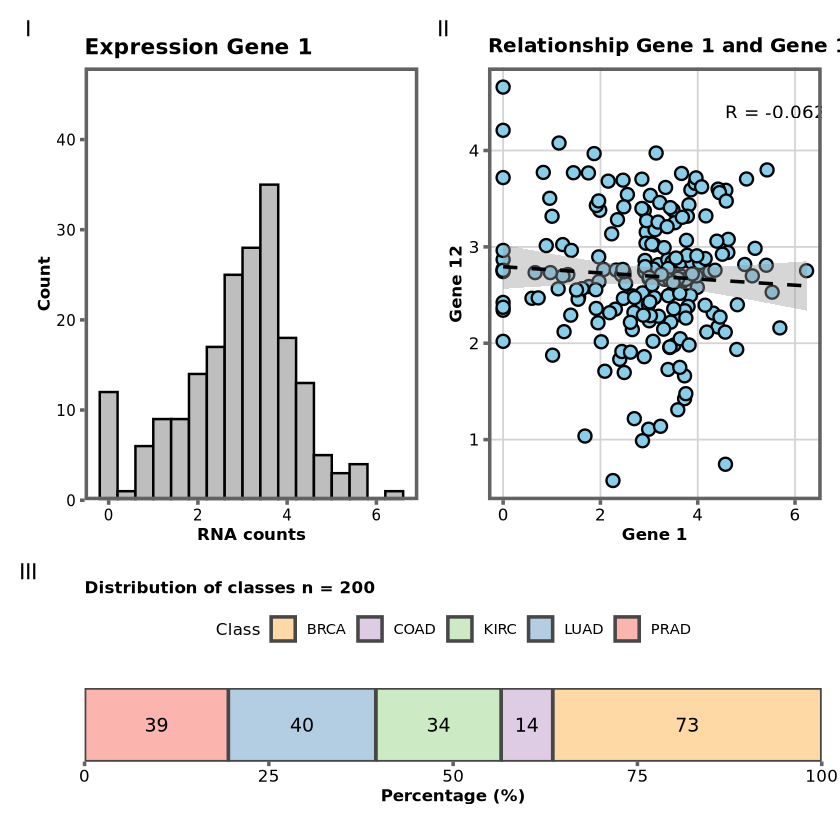

In [30]:
#combining all plots in one figure
composita_figure <-(histogram_plot | scatter_plot) / stacked_bar_plot +
  plot_layout(heights = c(4, 1)) +
  plot_annotation(tag_levels = 'I')

ggsave(file.path(output_dir, "composita_fig.png"), 
       composita_figure, width = 6, height = 5, dpi = 300)
print(composita_figure)

In [14]:
#loading and preparing hg38 gene data
hg38 <- read_tsv("data/hg38_genes.tsv")

#apply filtering and renaming
filtered_genes <- hg38 %>%
  filter(gene_type == "protein_coding" | 
           gene_type == "lncRNA" | 
           gene_type == "processed_pseudogene" | 
           gene_type == "transcribed_unprocessed_pseudogene") %>%
  #renamig gene type
  mutate(gene_type = replace(gene_type, gene_type == "protein_coding", "mRNA")) %>%
  mutate(gene_type = replace(gene_type, gene_type == "processed_pseudogene", "Pseudo")) %>%
  mutate(gene_type = replace(gene_type, gene_type == "transcribed_unprocessed_pseudogene", "Pseudo")) %>%
  #filtering specific gene length and add new lenght column
  mutate(length = end_gene - start_gene) %>%
  filter(length > 1000 & length <= 20000)

Rows: 20000 Columns: 7
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (5): chr, strand_gene, gene_name, ensembl_id, gene_type
dbl (2): start_gene, end_gene

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


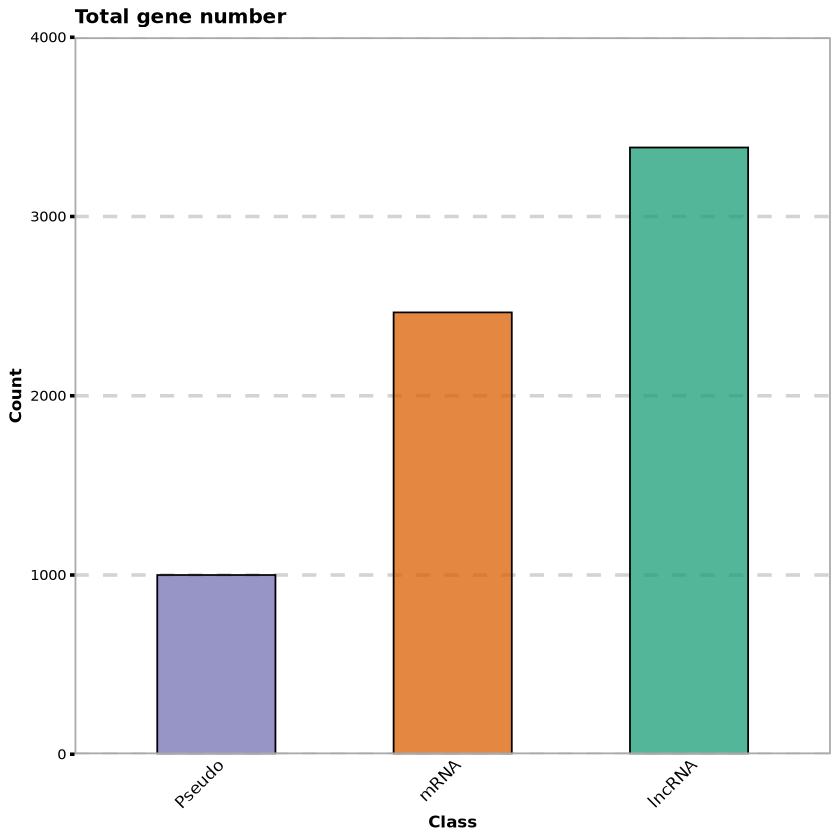

In [31]:
#plotting gene count
classic_barplot <- ggplot(filtered_genes, aes(x = gene_type, fill = gene_type)) + 
  geom_bar(color= "black", 
           linewidth= 0.5,  
           width = 0.5,
           alpha = 0.75) + 
  labs(title = "Total gene number" , 
       x = "Class", 
       y = "Count") +
  theme(panel.grid = element_blank(),
        panel.grid.major.y =  element_line(color = "lightgrey" ,linewidth = 1, linetype = "dashed"),
        panel.background = element_rect(fill = "white"),
        panel.border = element_rect(color = "darkgray", size = 1, fill = NA),
        plot.title = element_text(size = 12, face = "bold"),
        axis.title = element_text(size = 10, face = "bold"),
        axis.text.x = element_text(size = 10, color = "black", angle = 45, hjust = 1),
        axis.text.y = element_text(color = "black"),
        axis.ticks.y = element_line(color = "black", linewidth = 1),
        axis.ticks.x = element_blank(),
        legend.position = "none"
  ) + 
  scale_y_continuous(expand = c(0,0), limits = c(0, 4000)) +
  scale_x_discrete(limits = c("Pseudo", "mRNA", "lncRNA")) +
  scale_fill_discrete(type = (brewer.pal(3, "Dark2")))

ggsave(file.path(output_dir, "classic_barplot.png"), 
       classic_barplot, width = 6, height = 5, dpi = 300)

print(classic_barplot)

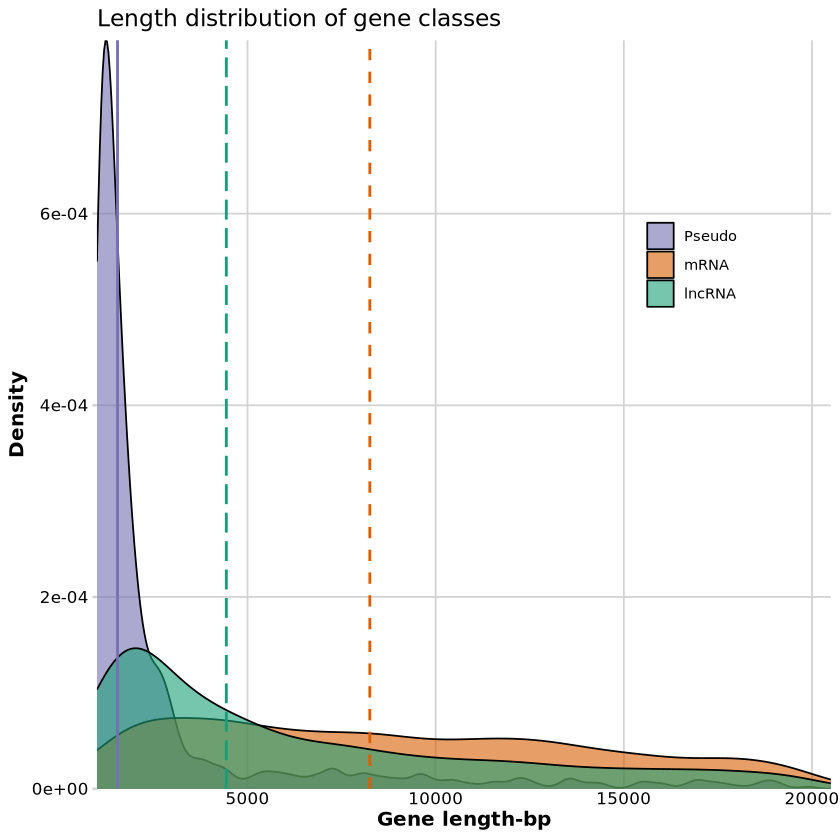

In [32]:
#creating denisty plot showing length distribution
#calculating the medians
median_mRNA <- median(filter(filtered_genes, gene_type == "mRNA")$length)
median_lncRNA <- median(filter(filtered_genes, gene_type == "lncRNA")$length)
median_Pseudo <- median(filter(filtered_genes, gene_type == "Pseudo")$length)


denisty_plot <- ggplot(filtered_genes, aes(x = length, fill = fct_rev(gene_type))) + 
  geom_density(alpha = 0.6, linewidth = 0.5) +
  geom_vline(xintercept = median_Pseudo, color = "#7570B3", linewidth = 0.8) + 
  geom_vline(xintercept = median_lncRNA, color = "#1B9E77", linetype = "longdash", linewidth = 0.8) +
  geom_vline(xintercept = median_mRNA, color = "#D95F02", linetype = "dashed", linewidth = 0.8) +
  scale_fill_discrete(type = rev(brewer.pal(3, "Dark2"))) +
  scale_y_continuous(expand = c(0,0)) +
  scale_x_continuous(expand = c(0,0), limits = c(1000,20500)) +
  labs(title = "Length distribution of gene classes" , x = "Gene length-bp", y = "Density") +
  theme(
    plot.title = element_text(size = 14),
    axis.title = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 10, color = "black"),
    axis.ticks.x =  element_blank(),
    axis.ticks.y = element_line(color = "lightgrey",linewidth = 0.7),
    panel.grid.major.x = element_line(color = "lightgrey" ,linewidth = 0.5),
    panel.grid.major.y =  element_line(color = "lightgrey" ,linewidth = 0.5),
    panel.border = element_blank(),
    panel.background = element_rect(fill = "white"),
    legend.position= c(0.81, 0.7),
    legend.background = element_rect(fill='transparent'),
    legend.title=element_blank()
  )

ggsave(file.path(output_dir, "densityplot.png"), 
       denisty_plot, width = 6, height = 5, dpi = 300)
print(denisty_plot)

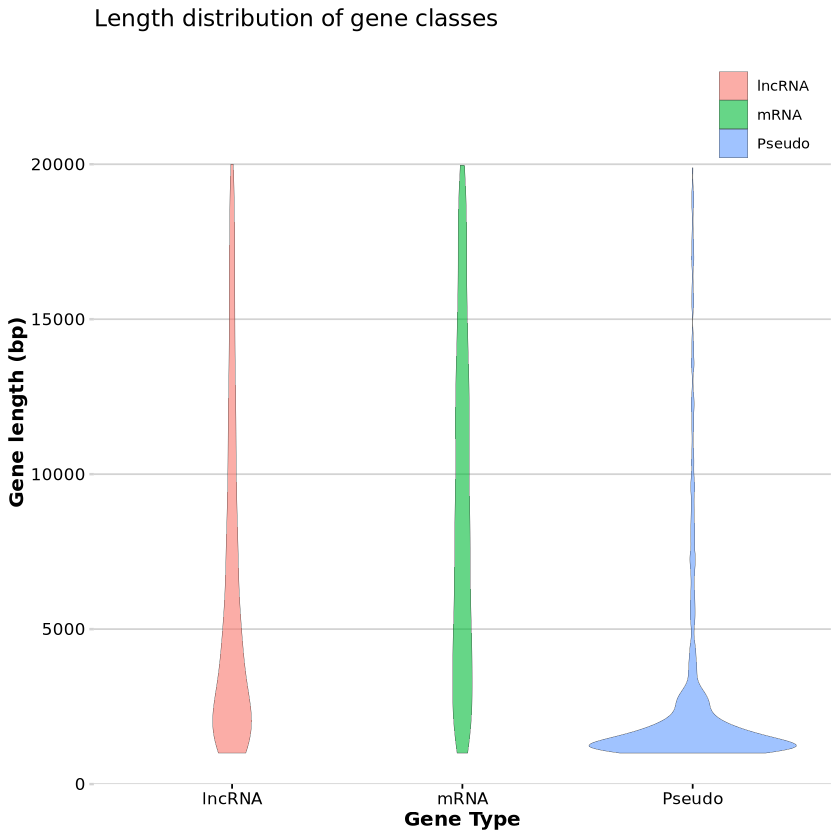

In [17]:
ggplot(filtered_genes, aes(x = gene_type, y = length, fill = gene_type)) + 
  geom_violin(alpha = 0.6, linewidth = 0.1) +
  scale_y_continuous(expand = c(0,0), limits = c(0, 24000)) +
  labs(title = "Length distribution of gene classes", x = "Gene Type", y = "Gene length (bp)") +
  theme(
    plot.title = element_text(size = 14),
    axis.title = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 10, color = "black"),
    axis.ticks.x = element_line(color = "black"),
    axis.ticks.y = element_line(color = "lightgrey", linewidth = 0.7),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(color = "lightgrey", linewidth = 0.5),
    panel.border = element_blank(),
    panel.background = element_rect(fill = "white"),
    legend.position = c(0.91, 0.9),
    legend.background = element_rect(fill = 'transparent'),
    legend.title = element_blank()
  )

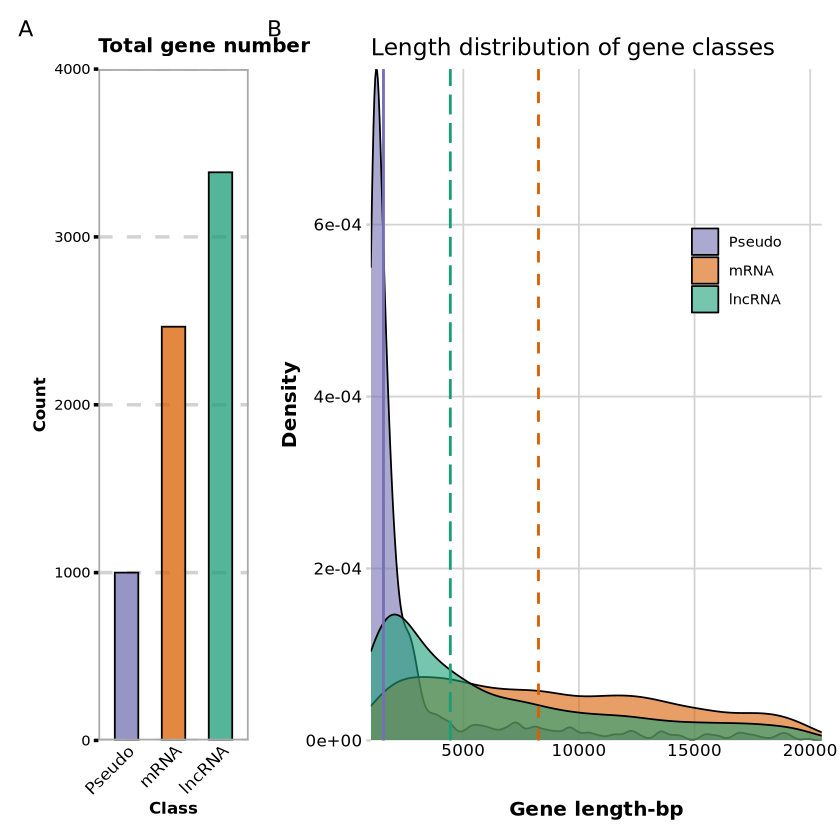

In [33]:
#combing both plots in one figure
denisty_barplots <- classic_barplot + 
  denisty_plot + 
  plot_layout(widths = c(1, 3)) +
  plot_annotation(tag_levels = 'A')


ggsave(file.path(output_dir, "density_compsita_plots.png"), 
       denisty_barplots, width = 6, height = 5, dpi = 300)
print(denisty_barplots)

In [19]:
#differential gene expression
#loading and filtering data by selecting the top 2000 highest value
#creating new discrete column showing regulation status 
deseq_data <- read.delim("data/deseq2_dummy.txt")
deseq_filtered <- deseq_data %>%
  arrange(desc(baseMean)) %>%
  head(2000) %>%
  mutate(Regulation = NA)

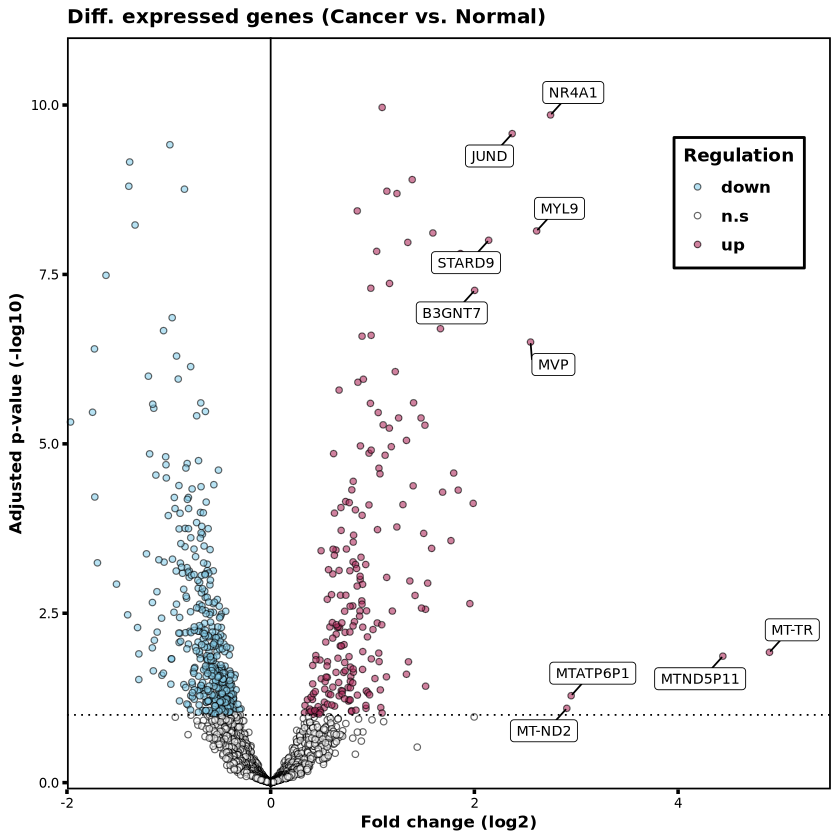

In [35]:
#looping over each row to select signifact gene regulation
#and assign up, down or n.s in regulation column
for (i in 1:nrow(deseq_filtered)){
  if (deseq_filtered[i, 8] <= 0.1 & deseq_filtered[i, 4] > 0){
    deseq_filtered[i, 15] <- "up"
  }
  else if (deseq_filtered[i, 8] <= 0.1 & deseq_filtered[i, 4] < 0){
    deseq_filtered[i, 15] <- "down"
  } 
  else deseq_filtered[i, 15] <- "n.s"
}


#variable for genes to be labeled on plot
gene_label <- filter(deseq_filtered, padj <= 0.1 & log2FoldChange >= 2)



#creating volcano plot
volcano_plot <- ggplot(deseq_filtered, aes(x = log2FoldChange, y = -log10(padj), fill = Regulation)) +
  geom_point(shape = 21, size = 1.5, colour = "black", alpha = 0.6) +
  geom_vline(xintercept = 0, col = "black") +
  geom_hline(yintercept = -log10(.1), col = "black", linetype = "dotted") +
  labs(title = "Diff. expressed genes (Cancer vs. Normal)" , x = "Fold change (log2)", 
       y = "Adjusted p-value (-log10)") +
  scale_y_continuous(expand = c(0,0), limits = c(-0.1,11)) +
  scale_x_continuous(expand = c(0,0), limits = c(-2,5.5)) +
  scale_fill_manual(values = c("up" = "maroon", "down" = "skyblue", "n.s" = "white")) +
  theme(panel.grid = element_blank(),
        panel.background = element_rect(fill = "white"),
        panel.border = element_rect(color = "black", size = 1, fill = NA),
        plot.title = element_text(size = 12, face = "bold"),
        axis.title = element_text(size = 10, face = "bold"),
        axis.text = element_text(size = 8, color = "black"),
        axis.ticks = element_line(color = "black", linewidth = 1),
        legend.position = c(0.88, 0.78),
        legend.box.background = element_rect(fill='transparent', linewidth = 0.8),
        legend.background = element_rect(fill = 'transparent'),
        legend.text = element_text(size = 10, face = "bold"),
        legend.title = element_text(face = "bold")
      
  ) +
  geom_label_repel(data = gene_label, aes(label = gene_id),
                   size = 3,
                   fill = "white",
                   color ="black",
                   box.padding = 0.4)

ggsave(file.path(output_dir, "volcano_plot.png"), 
       volcano_plot, width = 6, height = 5, dpi = 300)

print(volcano_plot)

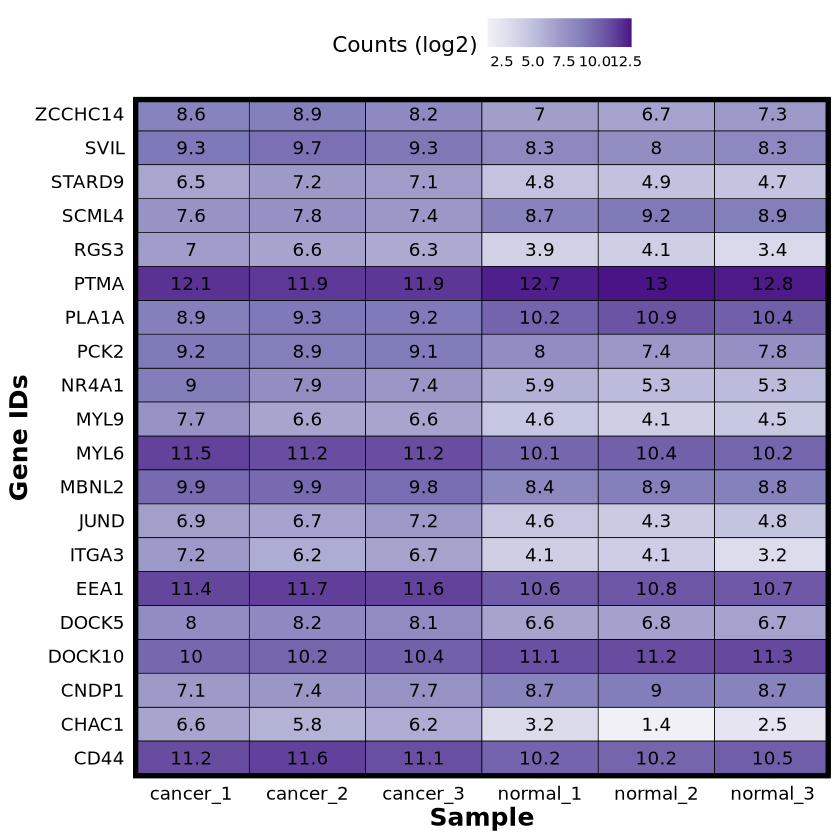

In [36]:
#RNAseq expression heatmap
# Take a subsample of the "dummy" DESeq2 output
deseq2_res_f <- deseq_data %>%
  slice_min(n = 20, order_by = padj)

# Create the plot
heatmap <- deseq2_res_f %>% 
  dplyr::select(gene_id, 9:14) %>%
  pivot_longer(cols = 2:7, names_to = "condition", values_to = "counts") %>% #changed 9:14 as it was already selected in previous line
  ggplot(aes(x = condition, y = gene_id, fill = log2(counts), label = round(log2(counts), digits = 1))) + #digits changed to 1
  geom_tile(color = "black") +
  geom_text(color = "black") + #color changed to black
  coord_cartesian(ylim = c(0.4, 20.5), expand = FALSE) + #removed expand and adjusted ylim
  scale_fill_distiller(palette = "Purples", direction = 1) + #applying direction to determine direction of color fading
  labs(x =  "Sample", y = "Gene IDs", fill = "Counts (log2)") +
  theme_minimal() +
  theme(legend.position = "top", 
        legend.ticks = element_blank(), 
        title = element_text(size = 13),
        axis.text = element_text(size = 11, colour = "black"),
        axis.title = element_text(size = 15, face = "bold"),
        panel.border = element_rect(size = 3, fill = NA)) #appling fall as NA to show layers

ggsave(file.path(output_dir, "heatmap.png"), 
       heatmap, width = 6, height = 5, dpi = 300)

print(heatmap)